In [1]:
from pymatgen.core import Structure
import numpy as np
import matplotlib.pyplot as plt 
import math
from pymatgen.analysis.diffraction.xrd import ATOMIC_SCATTERING_PARAMS


In [2]:
#struktura analogiczna jak robi pymatgen ale troche uproszczona
class StructureCONTCAR:
    def __init__(self,lattice,species,positions): #konstruktor na strukture
        self.lattice=lattice    #komorka elementarna wektory
        self.species=species    # jaki pierwiastek
        self.positions =positions      # jaki pierwiastek

In [3]:
def readCONTCAR2structure(lines):
    #linie 0 pomijam bo nie ma tam nic mi potrzebnego
    scale=float(lines[1].strip()) #zeby wymnozyc wektor ewentualnie, tu chyba wszędzie jest 1?

    #wektory
    lattice=[]
    for i in range(2, 5):
        vector=[float(x)*scale for x in lines[i].split()]
        lattice.append(vector)

    #jakie pierwiastki
    elements=lines[5].split()
    #ile atomów danego pierwiastka
    counts=[int(x) for x in lines[6].split()]
    species=[]
    for i in range(len(elements)):
        element=elements[i]  
        count=counts[i]
        species.extend([element] * count)

    #xyz dla kazdego atomu
    num_atoms=sum(counts)
    positions=[]
    for i in range(8,8 + num_atoms):
        line_data=lines[i].split()
        xyz=[float(x) for x in line_data[:3]]
        positions.append(xyz)

    return StructureCONTCAR(lattice, species, positions)

In [4]:
#test pymatgenowego 
structurePMG = Structure.from_file("CONTCAR1")
#print(f"{structurePMG.composition.formula}")
#print(f"{structurePMG.composition.reduced_formula}")
#print(f"{structurePMG.lattice}")
#print(f"{structurePMG.sites}")#w tym są jeszcze dodatkowe w angstremach ale to mnie chyba nie interesuje nawet

In [5]:
data = open("CONTCAR1").readlines()
structure1 = readCONTCAR2structure(data)


#test mojego
#print(structure1.lattice)
#print(structure1.species)
#print(structure1.positions)

In [6]:
#współczynniki abc dla jonów Ce4+,Pr3+,O2- w formacie [a1, b1, a2, b2, a3, b3, a4, b4, c]
#stałe wzięte z tabel
#http://lampx.tugraz.at/~hadley/ss1/crystaldiffraction/atomicformfactors/formfactors.php
#https://www.researchgate.net/publication/279973413_On_the_atomic_scattering_factor_for_O_2#fullTextFileContent

def atomicfactor(rodzaj,wavelength,sin_theta):
    f_atomic=0;
    if (rodzaj=='O'):
        wsp=[ 3.75040,2.84294,1.54298,1.62091,16.5151,6.59203,0.319201,43.3486,0.242060]
    elif (rodzaj=='Ce'):
         wsp=[19.3881,2.5804,18.2323,0.2078,11.2335,15.1102,1.8398,42.4208,3.2987]
    else: #(atom.specie.Z==59):
         wsp=[21.3727, 2.6452, 19.7491, 0.214299, 12.1329, 15.3230, 0.97518, 36.4065, 1.77132]
    Q=2*2*np.pi/wavelength*sin_theta
    G=(Q/4/np.pi)**2
    f_atomic=(wsp[0]*np.exp(-wsp[1]*G)+wsp[2]*np.exp(-wsp[3]*G)+wsp[4]*np.exp(-wsp[5]*G)+wsp[6]*np.exp(-wsp[7]*G)+wsp[8])
    return f_atomic

In [7]:
def atomicfactor2(rodzaj,wavelength,sin_theta):
    f_atomic=0;
    if (rodzaj=='O'):
        f_atomic=16
    elif (rodzaj=='Ce'):
        f_atomic=58
    else: #(atom.specie.Z==59):
        f_atomic=59
    
    return f_atomic

In [8]:
#ręczne liczenie ze wzorków #https://docs.lammps.org/compute_xrd.html
def CONTCAR2XRD(StructureCONTCAR, wavelength,min2theta, max2theta): 
    siatka = StructureCONTCAR.lattice #geometria komórki =>z tego gdzie piki
    polozenia = StructureCONTCAR.positions #rodzaj i położenia atomów =>z tego internywność 
    rodzaje=StructureCONTCAR.species;
    wyniki =[]
    for h in range(-12,13):
        for k in range(-12,13):
            for l in range(-12,13):
                if h==0 and k==0 and l==0: continue
    
                #liczymy odległości międzypłaszczynowe dla rodzin hkl
                #wymairy komorki elementarnej
                a=StructureCONTCAR.lattice[0]
                b=StructureCONTCAR.lattice[1]
                c=StructureCONTCAR.lattice[2]
                # objetosc komorki potrzebna do liczenia wektorow sieci odwrotnej
                V = np.dot(a,np.cross(b,c))
                
                #wektory odwrotne
                a_rec=np.cross(b,c)/V
                b_rec=np.cross(c,a)/V
                c_rec=np.cross(a,b)/V
                d_hkl=1.0/np.linalg.norm(h*a_rec+k*b_rec+l*c_rec)

                #prawo Braggów dla każdej z płaszczyzn n*lambda=2*d*sin(theta) dla n=1
                sin_theta=wavelength/(2*d_hkl)
                if sin_theta>1 : continue
                theta=np.arcsin(sin_theta)
                theta2=2*theta #podwajamy kąt do dyfraktogramu
                if ((theta2>math.radians(max2theta)) or (theta2<math.radians(min2theta))): continue #pomijam jak poza zakresem
    
    
                Lp_theta=(1+np.cos(theta2)**2)/(np.cos(theta)*np.sin(theta)**2) #Lorentz polarization factor
                F_hkl=0+0j
                s=sin_theta/wavelength
                #f_atomic=0;
                for i in range(len(rodzaje)):
                    
                    
                    f_atomic=atomicfactor(rodzaje[i],wavelength,sin_theta)
                    xyz =polozenia[i]
                    #2*pi*i*(h*x + k*y + l*z)
                    faza=2*np.pi*(h*xyz[0]+k*xyz[1]+l*xyz[2])
                    F_hkl+=f_atomic*np.exp(1j*faza)
                I=Lp_theta*np.abs(F_hkl)**2 #intensywność danego piku
                wyniki.append({"hkl": (h,k,l), "2theta": math.degrees(theta2),"intensity": I})
                
    return wyniki

wczytano: CONTCAR1
wczytano: CONTCAR2
wczytano: CONTCAR3
wczytano: CONTCAR4


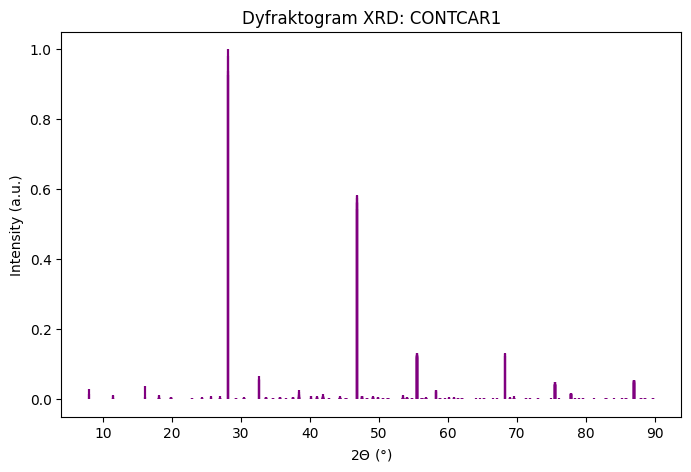

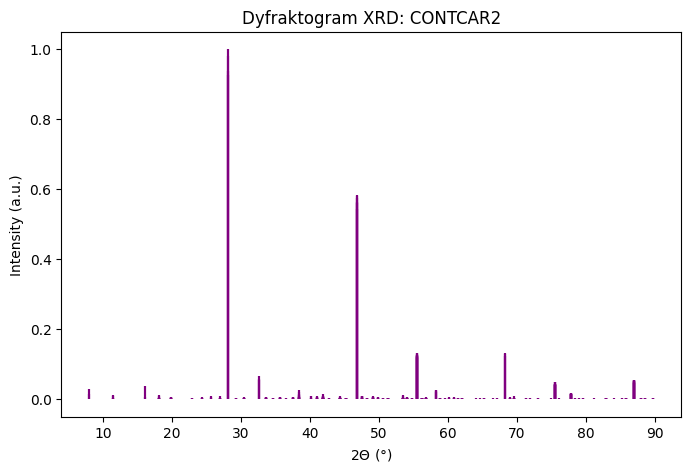

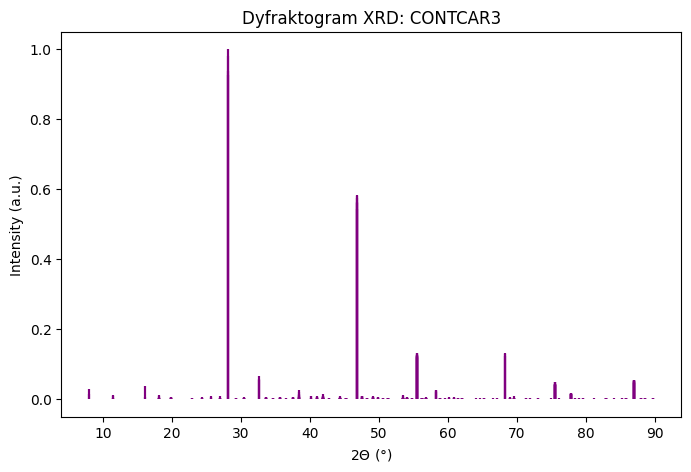

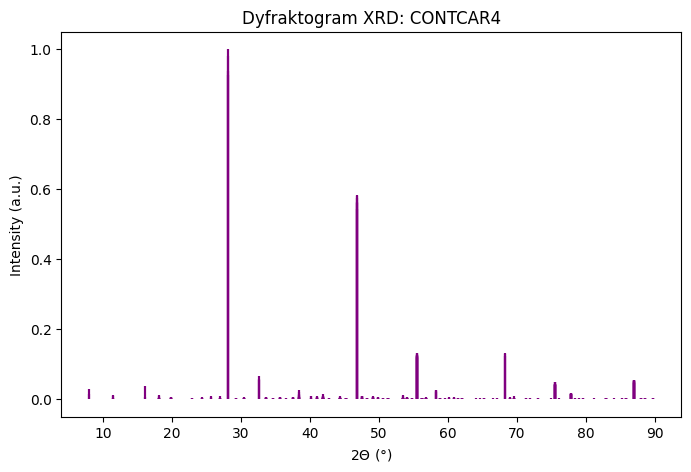

In [10]:
lambda_cu=1.5418 #lampa anoda Cu, taka chyba u nas na wydziale
structures=[]
for i in range(1, 5):
    filename=f"CONTCAR{i}"
    data=open("CONTCAR1").readlines()
    struct=readCONTCAR2structure(data)
    structures.append(struct)
    print(f"wczytano: {filename}")


def norm(y):
    y = np.array(y)
    if np.max(y) == 0: return y
    return y / np.max(y)


for i, struct in enumerate(structures, start=1):
    piki=CONTCAR2XRD(struct, lambda_cu, 0, 90)
        
    x=np.array([p["2theta"] for p in piki])
    y=np.array([p["intensity"] for p in piki])

    plt.figure(figsize=(8, 5))
    plt.vlines(x, 0, norm(y), colors='#800080', linewidth=1.5)
    plt.title(f"Dyfraktogram XRD: CONTCAR{i}")
    plt.xlabel(r"2$\Theta$ ($\degree$)")
    plt.ylabel("Intensity (a.u.)")

    plt.savefig(f"xrd{i}.png")
    plt.show()


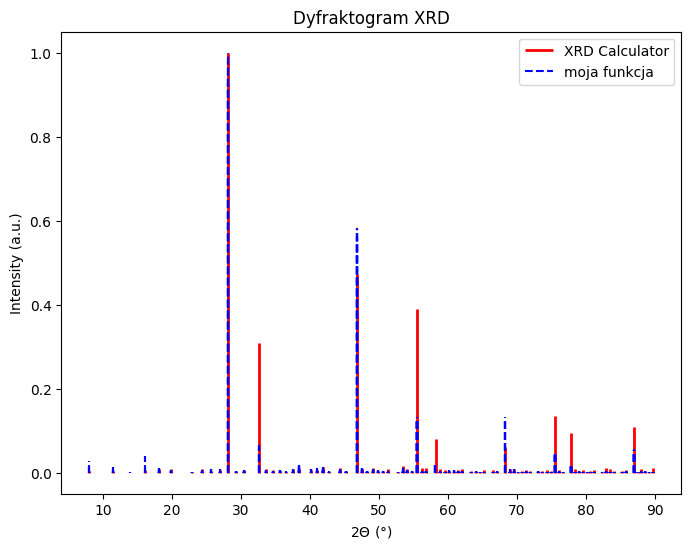

In [11]:
from pymatgen.core import Structure
from pymatgen.analysis.diffraction.xrd import ATOMIC_SCATTERING_PARAMS
from pymatgen.analysis.diffraction.xrd import XRDCalculator

#z gotowej funkcji xrdcalculator
structure=Structure.from_file("CONTCAR1")
wynik_xrd_calculator=XRDCalculator(wavelength='CuKa')
dane=wynik_xrd_calculator.get_pattern(structure)
plt.figure(figsize=(8, 6))

plt.vlines(np.array(dane.x), 0, norm(dane.y), colors='red', lw=2, label='XRD Calculator')
plt.vlines( x,0, norm(y), colors='blue',linestyles='dashed', linewidth=1.5, label='moja funkcja')
plt.title(f"Dyfraktogram XRD")
plt.xlabel(r"2$\Theta$ ($\degree$)")
plt.ylabel("Intensity (a.u.)")
plt.legend()
plt.savefig("xrd.png")
plt.show()